**Exploratory Data Analaysis for Outliers & Outlier Detection**

- Outliers standout

- In data science, we are looking at data points far away from the rest of the observations.

- Bad outliers(Typo)

- Good Outliers (Unusual Activities)

- Averages are highly to outliers

**Spotting the black sheep**

*Data of Interest:* Housing data

In [80]:
# import the modules for our EDA workflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as st
from IPython.display import Image
import matplotlib

In [81]:
# Read our dataset of interest
housing_data = pd.read_csv('/kaggle/input/datasets/awofiranyejames/house-prices/house_prices.csv')
housing_data.head(2)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00


Outcomes:
1. We need to build a housing price predictor
2. We have sat with our team of real-estate experts
3. We concluded that the data must reflect a normal distribution

In [82]:
# Create DataFrame Pipelines
# Start with an original checkpoint for our dataframe
housing_data_one = housing_data.copy()

In [83]:
# Concise Summary
housing_data_one.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [84]:
# The marketing team and the real estate team explained that some features are unnecessary
# area_type, availability, society & balcony
# We will drop the listed features from the dataframe
housing_data_one.drop(columns=['area_type', 'availability', 'society', 'balcony'], axis=1, inplace=True)
housing_data_one.head(2)

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00


In [85]:
# Check for missing data
housing_data_one.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [86]:
# We would do away with missing data
# Caveat: This is not best practice
# 2nd DataFrame Pipeline
housing_data_two = housing_data_one.copy()

In [87]:
# Drop rows with missing values
# This is not a best practice
housing_data_two.dropna(inplace=True)

In [88]:
housing_data_two.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

In [89]:
# Evaluate all features
housing_data_two.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13246 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13246 non-null  object 
 1   size        13246 non-null  object 
 2   total_sqft  13246 non-null  object 
 3   bath        13246 non-null  float64
 4   price       13246 non-null  float64
dtypes: float64(2), object(3)
memory usage: 620.9+ KB


In [90]:
# Evaluate the size column
housing_data_two['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [91]:
# What is BHK?
# Bedrooms, Hall, & Kitchen
# Feature-engineer the size column
housing_data_two['bhk'] = housing_data_two['size'].apply(lambda x: int(x.split(' ')[0]))

In [92]:
housing_data_two.head(2)

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4


In [93]:
# Concise Summary
housing_data_two.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13246 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13246 non-null  object 
 1   size        13246 non-null  object 
 2   total_sqft  13246 non-null  object 
 3   bath        13246 non-null  float64
 4   price       13246 non-null  float64
 5   bhk         13246 non-null  int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 724.4+ KB


In [94]:
# Create the 3rd dataframe pipeline
housing_data_three = housing_data_two.copy()

In [95]:
# Evaluate the total_sqft column
# Check the uniqueness of the column values
housing_data_three['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [96]:
# Convert to floats
# Create a function that converts to float
def is_float(x):
  try:
    float(x)
  except:
    return False
  return True

In [97]:
# Apply to the column
housing_data_three[housing_data_three['total_sqft'].apply(is_float)].head(20)

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2
5,Whitefield,2 BHK,1170,2.0,38.00,2
6,Old Airport Road,4 BHK,2732,4.0,204.00,4
7,Rajaji Nagar,4 BHK,3300,4.0,600.00,4
8,Marathahalli,3 BHK,1310,3.0,63.25,3
9,Gandhi Bazar,6 Bedroom,1020,6.0,370.00,6


In [98]:
# Use the negate operator
housing_data_three[~housing_data_three['total_sqft'].apply(is_float)].head(20)

,location,size,total_sqft,bath,price,bhk
30,Yelahanka,4 BHK,2100 - 2850,4.0,186.000,4
122,Hebbal,4 BHK,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,54.005,2
165,Sarjapur,2 BHK,1145 - 1340,2.0,43.490,2
188,KR Puram,2 BHK,1015 - 1540,2.0,56.800,2
410,Kengeri,1 BHK,34.46Sq. Meter,1.0,18.500,1
549,Hennur Road,2 BHK,1195 - 1440,2.0,63.770,2
648,Arekere,9 Bedroom,4125Perch,9.0,265.000,9
661,Yelahanka,2 BHK,1120 - 1145,2.0,48.130,2
672,Bettahalsoor,4 Bedroom,3090 - 5002,4.0,445.000,4


In [99]:
# Create a function to deal with values that have dashes
def convert_sqft_to_num(x):
  tokens = x.split('-')
  if len(tokens) == 2:
   return (float(tokens[0]) + float(tokens[1]))/ 2
  try:
    return float(x)
  except:
    return None

In [100]:
convert_sqft_to_num('520 - 645')

582.5

In [101]:
housing_data_three.shape

(13246, 6)

In [102]:
# We will apply the convert function to the column
housing_data_three['total_sqft'] = housing_data_three['total_sqft'].apply(convert_sqft_to_num)

In [103]:
housing_data_three.head(2)

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4


In [104]:
housing_data_three.shape

(13246, 6)

In [105]:
housing_data_three.isnull().sum()

location       0
size           0
total_sqft    46
bath           0
price          0
bhk            0
dtype: int64

In [106]:
# Fourth DataFrame Pipeline
housing_data_four = housing_data_three.copy()

In [107]:
housing_data_four.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13246 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13246 non-null  object 
 1   size        13246 non-null  object 
 2   total_sqft  13200 non-null  float64
 3   bath        13246 non-null  float64
 4   price       13246 non-null  float64
 5   bhk         13246 non-null  int64  
dtypes: float64(3), int64(1), object(2)
memory usage: 724.4+ KB


In [108]:
# Feature-engineer the price column
# Create the price_per_sqft(100)
housing_data_four['price_per_sqft(100)'] = housing_data_four['price'] * 100 / housing_data_four['total_sqft']

In [109]:
Housing_data_four.head(2)

NameError: name 'Housing_data_four' is not defined

**Time to Spot the Black Sheep**

In [ ]:
# What is the normal size for one-bedroom apartment?
# Response: A one-room apartment is normally 300 sqft
# If a one-bedroom is normally 300 sqft, an unusual room may be far less or much higher

In [111]:
600/8

75.0

In [110]:
# Focus will be on bhks with less than 300 sqft
housing_data_four[housing_data_four['total_sqft']/ housing_data_four['bhk'] < 300].head(30)

,location,size,total_sqft,bath,price,bhk,price_per_sqft(100)
9,Gandhi Bazar,6 Bedroom,1020.0,6.0,370.0,6,36.274510
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33.333333
58,Murugeshpalya,6 Bedroom,1407.0,4.0,150.0,6,10.660981
68,Devarachikkanahalli,8 Bedroom,1350.0,7.0,85.0,8,6.296296
70,Double Road,3 Bedroom,500.0,3.0,100.0,3,20.000000
78,Kaval Byrasandra,2 BHK,460.0,1.0,22.0,2,4.782609
89,Rajaji Nagar,6 Bedroom,710.0,6.0,160.0,6,22.535211
119,Hennur Road,2 Bedroom,276.0,3.0,23.0,2,8.333333
129,Vishwapriya Layout,7 Bedroom,950.0,7.0,115.0,7,12.105263
149,Dinnur,6 Bedroom,1034.0,5.0,185.0,6,17.891683


In [112]:
# Look at the shape of the dataframe
housing_data_four.shape

(13246, 7)

In [113]:
# 5th DataFrame Pipeline
housing_data_five = housing_data_four.copy()

In [116]:
# Remove the black sheep of the unusual room sizes
housing_data_five = housing_data_five[~(housing_data_five['total_sqft']/ housing_data_five['bhk'] < 300)]

In [117]:
housing_data_five.shape

(12502, 7)

In [118]:
13246 - 12502

744

**Spotting the Black Sheep(PT2): Removal of Outliers Using Statistical Concepts & Imputation**

In [ ]:
# The Distribution of Values Regarding Standard Deviation
# The Normal Distribution
# Metrics of a Normal Distribution

In [120]:
# A Python list containing 10 arbitrary values(Age)
ages = [20, 25, 23, 45, 89, 101, 15, 45, 63, 34]
# Mean age: 46 years
# STD age: 30 years
# Median age: 40 years

In [121]:
# What is the mean age of the age distribution?
st.mean(ages)

46

In [122]:
# What is the Standard Deviation of the age distribution
st.stdev(ages)

29.657301892713633

In [123]:
# Median Age
st.median(ages)

39.5

In [ ]:
# We have 3 standard deviations for the distributions of values
# One STD + or - from the mean

# For Price Per Sqft(100) > (Mean - STD)
# For Price Per Sqft(100) <= (Mean + STD)
# The Normal Distribution - 68%

In [124]:
housing_data_five.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft(100)
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3.699811
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4.615385
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4.305556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6.245891
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4.250000


In [125]:
# The 6th Pipeline
housing_data_six = housing_data_five.copy()

In [126]:
housing_data_six.shape

(12502, 7)

In [127]:
# Location & Price Per Sqft
housing_data_six['location'].head()

0    Electronic City Phase II
1            Chikka Tirupathi
2                 Uttarahalli
3          Lingadheeranahalli
4                    Kothanur
Name: location, dtype: object

In [128]:
housing_data_six['price_per_sqft(100)'].head()

0    3.699811
1    4.615385
2    4.305556
3    6.245891
4    4.250000
Name: price_per_sqft(100), dtype: float64

In [129]:
# The Summary Statistics
housing_data_six['price_per_sqft(100)'].describe()

count    12456.000000
mean         6.308503
std          4.168127
min          0.267830
25%          4.210526
50%          5.294118
75%          6.916667
max        176.470588
Name: price_per_sqft(100), dtype: float64

In [ ]:
# The Mean price_per_sqft(100): 6.3
# The STD price_per_sqft(100): 4.1
# One STD + or - from the mean

# For Price Per Sqft(100) > (Mean - STD)
# For Price Per Sqft(100) <= (Mean + STD)
# The Normal Distribution - 68%

In [130]:
# Our Function
def remove_pps_outliers(df):
  df_outcome = pd.DataFrame()
  for key, subdf in df.groupby('location'):
    mean = np.mean(subdf['price_per_sqft(100)'])
    std = np.std(subdf['price_per_sqft(100)'])
    extract_df = subdf[(subdf['price_per_sqft(100)'] > (mean - std)) & (subdf['price_per_sqft(100)'] <= (mean + std))]
    df_outcome = pd.concat([df_outcome, extract_df], ignore_index=True)
  return df_outcome

In [ ]:
housing_data_five.shape

In [131]:
# Apply & Remove our outliers
housing_data_six = remove_pps_outliers(housing_data_six)

In [132]:
housing_data_six.shape

(9261, 7)

In [133]:
12502 - 9261

3241

In [134]:
# First few rows of our dataframe
housing_data_six.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft(100)
0,Devarabeesana Halli,3 BHK,1672.0,3.0,150.0,3,8.971292
1,Devarabeesana Halli,3 BHK,1750.0,3.0,149.0,3,8.514286
2,Devarabeesana Halli,3 BHK,1750.0,3.0,150.0,3,8.571429
3,Devarachikkanahalli,3 BHK,1250.0,2.0,44.0,3,3.520000
4,Devarachikkanahalli,2 BHK,1250.0,2.0,40.0,2,3.200000


**We must visualize the data to spot any black sheep**

In [135]:
# The 7th Pipeline
housing_data_seven = housing_data_six.copy()

In [136]:
# The breakdown of the bhks
housing_data_seven['bhk'].value_counts(normalize=True)

bhk
2     0.468524
3     0.393370
4     0.070187
1     0.049023
5     0.009934
6     0.005291
8     0.001512
7     0.001404
9     0.000648
10    0.000108
Name: proportion, dtype: float64

In [137]:
# Interests: Price, Location & BHK
# Create a function to visualize the price based on location, size of bhks
def plot_scatter_chart(df, location):
 bhk2 = df[(df['location'] == location) & (df['bhk']==2)]
 bhk3 = df[(df['location'] == location) & (df['bhk']==3)]
 matplotlib.rcParams['figure.figsize'] = (12, 10)
 plt.scatter(bhk2['total_sqft'], bhk2['price'], color='blue', label='2 BHK', s=50)
 plt.scatter(bhk3['total_sqft'], bhk3['price'], marker= '+', color='green', label='3 BHK', s=50)
 plt.xlabel('Total Square Feet Area')
 plt.ylabel('Price')
 plt.title(location)
 plt.legend()

In [138]:
# Check Unique Locations
housing_data_seven['location'].unique()

array([' Devarabeesana Halli', ' Devarachikkanahalli', ' Electronic City',
       ' Mysore Highway', ' Rachenahalli', ' Thanisandra', ' south',
       '1st Block BEL Layout', '1st Block HBR Layout',
       '1st Block HRBR Layout', '1st Block Jayanagar',
       '1st Block Koramangala', '1st Phase JP Nagar',
       '1st Stage Indira Nagar', '2nd Block Hrbr Layout',
       '2nd Block Jayanagar', '2nd Phase JP Nagar',
       '2nd Phase Judicial Layout', '2nd Stage Arekere Mico Layout',
       '2nd Stage Nagarbhavi', '3rd Block Banashankari',
       '3rd Block Hrbr Layout', '3rd Block Jayanagar',
       '3rd Block Koramangala', '3rd Phase JP Nagar',
       '4th Block Jayanagar', '4th Block Koramangala',
       '4th Phase JP Nagar', '4th T block Jayanagar',
       '5th Block Hbr Layout', '5th Phase JP Nagar',
       '5th Stage BEML Layout', '6th Phase JP Nagar',
       '6th block Koramangala', '7th Block Jayanagar',
       '7th Phase JP Nagar', '8th Block Jayanagar', '8th Phase JP Nagar',
  

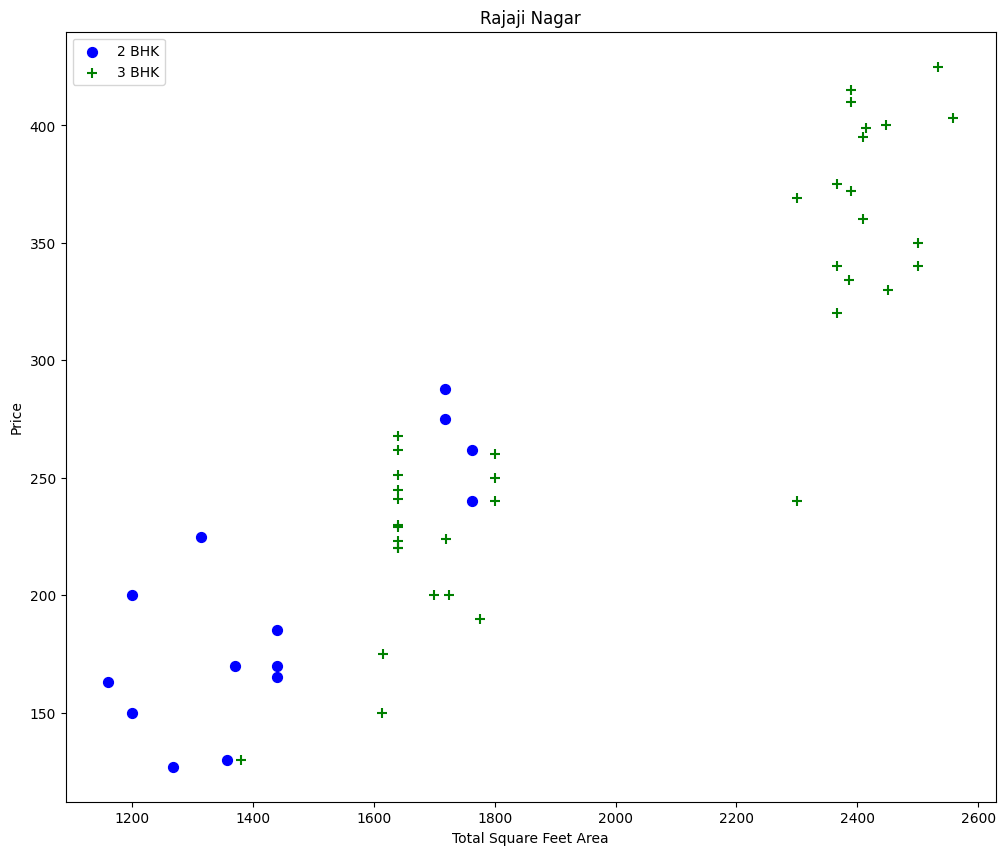

In [139]:
# Visualize the location - bhk, total sqft
plot_scatter_chart(housing_data_seven, 'Rajaji Nagar')

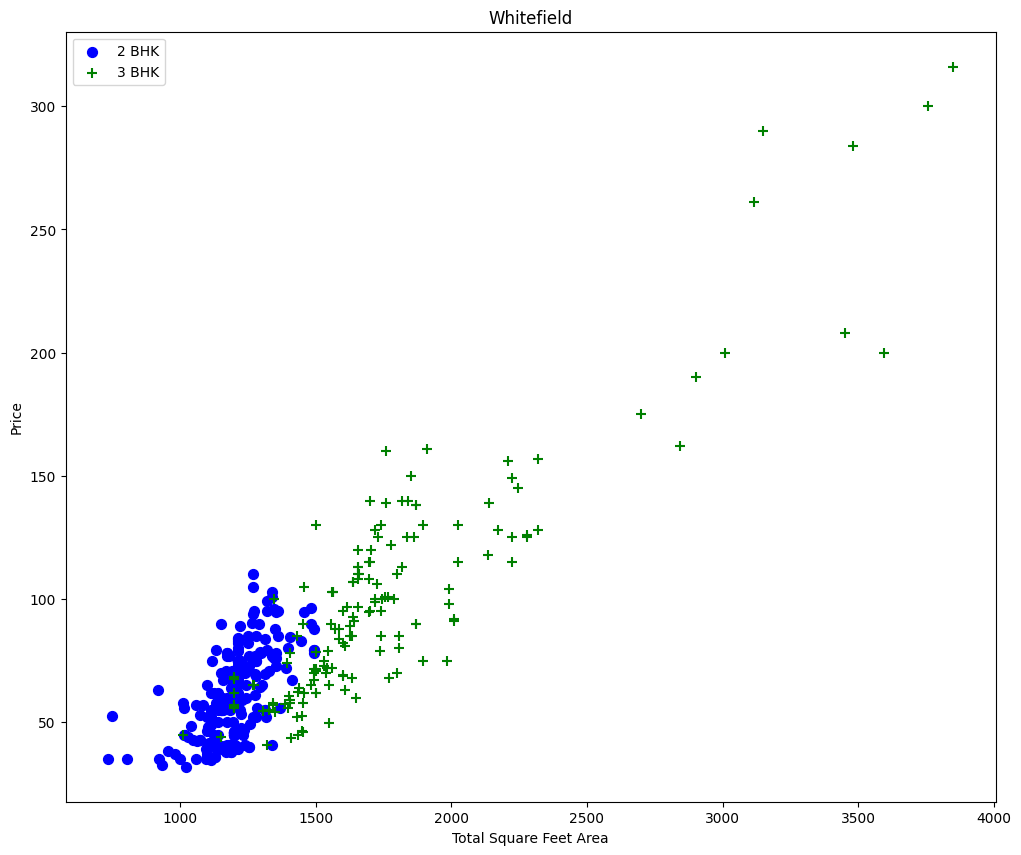

In [140]:
# Visualize Whitefield
plot_scatter_chart(housing_data_seven, 'Whitefield')

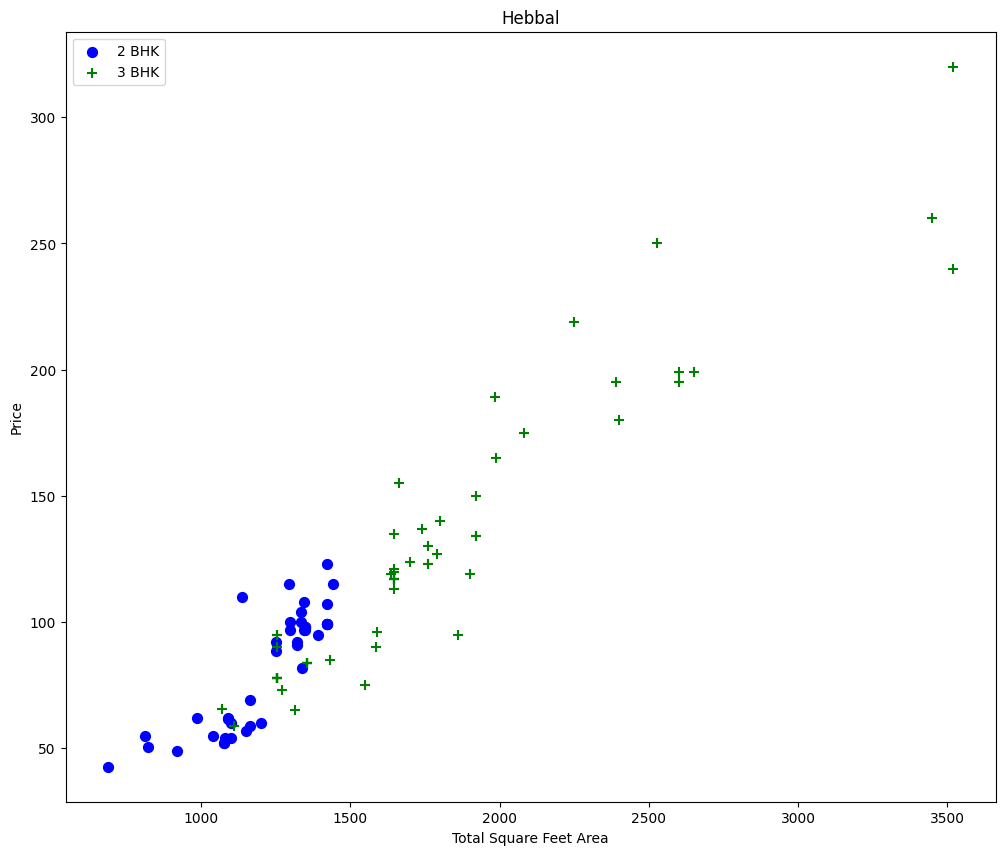

In [141]:
# Visualize
plot_scatter_chart(housing_data_seven, 'Hebbal')

In [ ]:
# High-Level Meeting
# In the same neighborhood, a 2-bhk shouldn't cost more than a 3-bhk
# If that happens, it may be an error, a damaged property, or a rarity(Outliers)

In [142]:
def remove_bhk_outliers(df):
  exclude_indices = np.array([])
  for location, location_df in df.groupby('location'):
    bhk_stats = {}
    for bhk, bhk_df in location_df.groupby('bhk'):
      bhk_stats[bhk] = {
          'mean': np.mean(bhk_df['price_per_sqft(100)']),
          'std': np.std(bhk_df['price_per_sqft(100)']),
          'count': bhk_df.shape[0]
      }

    for bhk, bhk_df in location_df.groupby('bhk'):
      stats = bhk_stats.get(bhk-1)
      if stats and stats['count'] > 5:
        exclude_indices = np.append(exclude_indices, bhk_df[bhk_df['price_per_sqft(100)']<(stats['mean'])].index.values)
  return df.drop(exclude_indices, axis='index')

In [143]:
# The 8th Pipeline
housing_data_eight = housing_data_seven.copy()

In [144]:
housing_data_seven.shape

(9261, 7)

In [145]:
# Remove the outliers
housing_data_eight = remove_bhk_outliers(housing_data_eight)

In [146]:
housing_data_eight.shape

(7511, 7)

In [147]:
9261 - 7511

1750

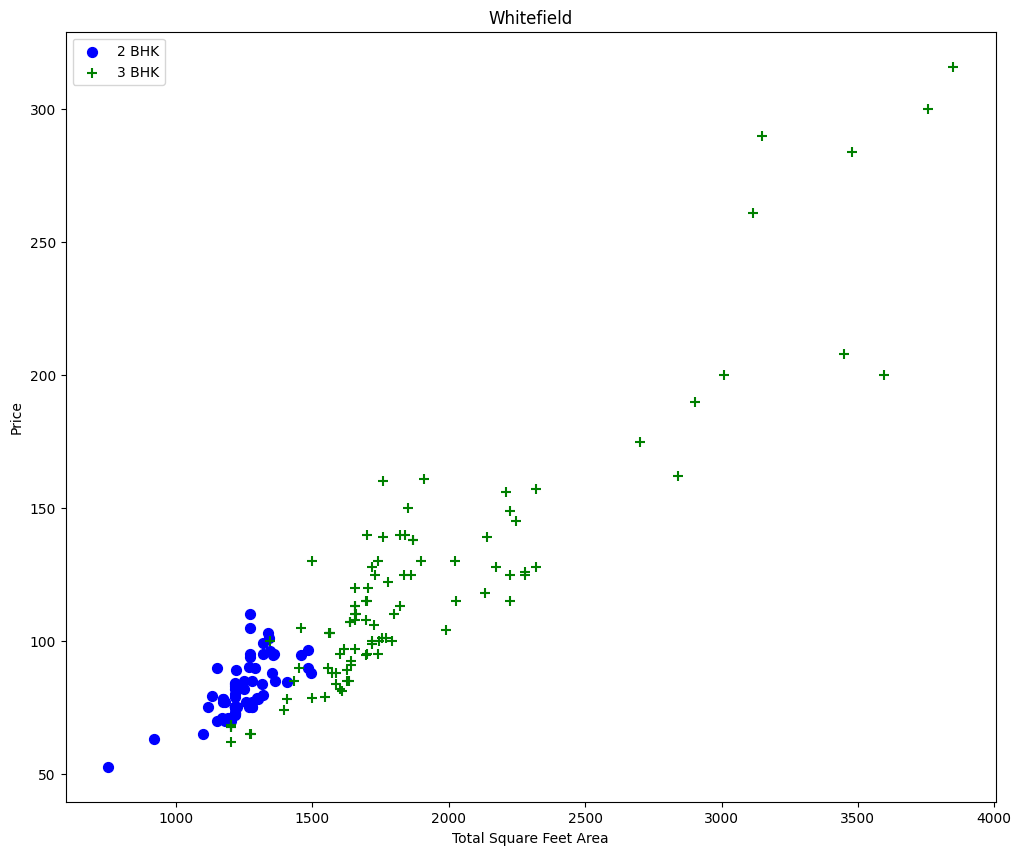

In [148]:
# Visualize Whitefield
plot_scatter_chart(housing_data_eight, 'Whitefield')

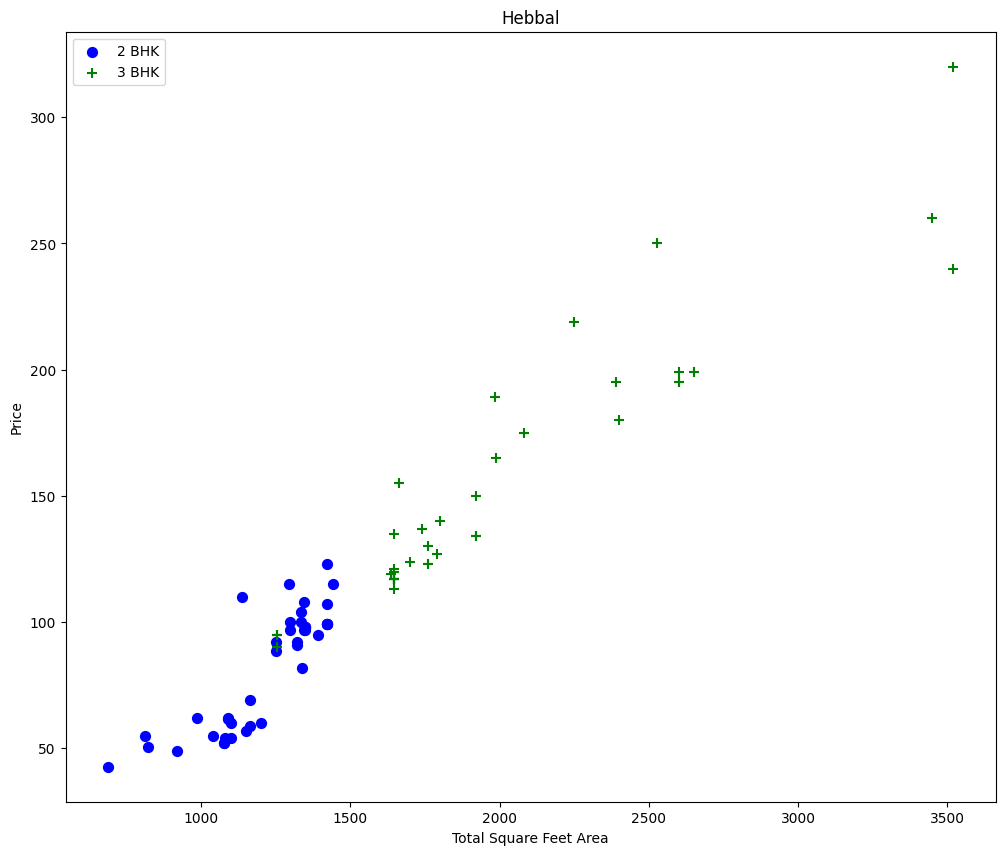

In [149]:
# Visualize
plot_scatter_chart(housing_data_eight, 'Hebbal')

**Pseudo-code for the remove_bhk_outliers function**

Line-by-Line Breakdown
1. def remove_bhk_outliers(df):

What it does: Defines the function name and accepts your DataFrame (df) as input.

Note: bhk stands for Bedroom, Hall, Kitchen. It's just a variable for the number of bedrooms.

2. exclude_indices = np.array([])

What it does: Creates an empty list (technically a NumPy array) that acts as a "trash can."

Why: We will store the ID numbers (indices) of all the bad rows we find here, so we can delete them all at once at the end.

3. for location, location_df in df.groupby('location'):

What it does: This starts a loop that goes through every unique neighborhood in your dataset one by one.

Why: Real estate rules change by area. You can't compare prices in a rich neighborhood with prices in a developing one. We isolate the data (location_df) for just one location at a time (e.g., "Whitefield") to analyze it fairly.

4. bhk_stats = {}

What it does: Creates an empty dictionary (a lookup table) for the current location.

Goal: We will fill this with the "Average Price" for a 1-bedroom, 2-bedroom, etc., so we have a benchmark to compare against.

5. for bhk, bhk_df in location_df.groupby('bhk'):

What it does: Inside the current location, we loop through each bedroom count (1 BHK, 2 BHK, etc.).

Example: First, we grab all the 1-Bedroom houses in Whitefield.

6. bhk_stats[bhk] = { ... }

What it does: We are now writing into our dictionary (lookup table). For the current bedroom size (e.g., "2 BHK"), we store three facts:

7. 'mean': np.mean(bhk_df.price_per_sqft): The average price per square foot.

8. 'std': np.std(bhk_df.price_per_sqft): The standard deviation (how much prices vary).

9. 'count': bhk_df.shape[0]: How many of these houses exist in the data.

10. for bhk, bhk_df in location_df.groupby('bhk'):

What it does: Now that we built our lookup table (the "Knowledge"), we loop through the bedroom groups again to apply the "Filter."

11. stats = bhk_stats.get(bhk-1)

What it does: This is the core comparison logic. It looks up the stats for the previous bedroom size (bhk-1).

Example: If we are currently looking at 3-Bedroom houses (bhk), this line grabs the average price of 2-Bedroom houses (bhk-1).

12. if stats and stats['count'] > 5:

What it does: A safety check.

Logic: It asks, "Do we actually have data for the smaller bedroom size? And do we have enough data (more than 5 houses) to trust that average?" If we only had 1 small house, comparing against it wouldn't be fair.

13. exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)

What it does: The Rule Enforcer.

The Logic: It looks at all the houses in the current group (e.g., 3-Bedroom). If any 3-Bedroom house has a price_per_sqft that is LOWER than the mean price of the 2-Bedroom houses (stats['mean']), it is marked as an outlier.

Action: It grabs the ID (index.values) of those bad rows and throws them into our "trash can" (exclude_indices).

14. return df.drop(exclude_indices, axis='index')

What it does: Finally, it takes the original DataFrame, looks at the "trash can" of indices we collected, and permanently deletes (drop) those rows. It then returns the clean dataset.